In [1]:
import numpy as np
import pandas as pd
from helpers.data_helpers import *
import matplotlib.pyplot as plt
import csv

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# Below identifiers correspond to evaluation protocol 1, 2 and 3 respectively
# identifiers - "TouchPose_crossSession", "TouchPose_crossSubjects", "TouchPose_crossGestures"
identifier = "TouchPose_crossGestures"
data_path = "../data/eth_data/"
model_path = "../models/"
new_data = "../data/27Arish"

# Information from Report

**Skeleton Data**   
The valid skeleton data we collected from leap motion controller covered 147 trails,
with an average number of frames per trail of 1316. The frame rate of Leap motion data is
30 fps. 

**Cap_img data**   
The capacity image and stylus data were recorded from Wacom tablet. The capacitive
image has the resolution 72*42. We collected 132 trails of capacity image and 201 trails
of pen data in total. The average number of frames of capacitive data per trial is 13203
frames, and the number of frames of pen data per trial is 12262. The recording rate is
about 80 fps. 

In [4]:
cap_text_cols = ['TimeStamps', 'MergeTimeStamps', 'ScanSizeX', 'ScanSizeY']
cap_numeric_cols =  list(map(str,range(3024)))
cap_cols = cap_text_cols + cap_numeric_cols
wrist_cols = ['wrist_x','wrist_y','wrist_z']
finger_cols = sum([[f'{x}_{y}_x', f'{x}_{y}_y', f'{x}_{y}_z'] for x in ['Thumb','Index','Middle','Ring','Pinky'] for y in range(5)],[]) 
skel_cols = ['Timestamp'] + wrist_cols + finger_cols
last_fingers_cols = [x for x in finger_cols if '_4_' in x]
sniffer = csv.Sniffer()

#read cap img files for 6 gestures
cap_img1 = read_cap_img("../data/DATA3003/16Yaman/YAMAN_1_UP_100_rawdata.csv",sniffer,cap_cols)
cap_img2 = read_cap_img("../data/DATA3003/16Yaman/YAMAN_2_DT_100_rawdata.csv",sniffer,cap_cols)
cap_img3 = read_cap_img("../data/DATA3003/16Yaman/YAMAN_3_DQ_100_rawdata.csv",sniffer,cap_cols)
cap_img4 = read_cap_img("../data/DATA3003/16Yaman/YAMAN_4_LQ_100_rawdata.csv",sniffer,cap_cols)
cap_img5 = read_cap_img("../data/DATA3003/16Yaman/YAMAN_5_LT_100_rawdata.csv",sniffer,cap_cols)
cap_img6 = read_cap_img("../data/DATA3003/16Yaman/YAMAN_6_UP_100_rawdata.csv",sniffer,cap_cols)
#concat into one file
cap_img = pd.concat([cap_img1,cap_img2,cap_img3,cap_img4,cap_img5,cap_img6],ignore_index=True )
#process cap_img with truncation
cap_img = process_cap_img(cap_img,trunc=True)
skeleton = read_skeleton("../data/DATA3003/16Yaman/useryaman_2023-03-30_11-35-18_1644_handleap.csv",sniffer,skel_cols)
#process skeleton with truncation
skeleton = process_skeleton(skeleton,last_fingers_cols,trunc=True)

In [5]:
print(cap_img.dtypes)
skeleton.dtypes

Timestamp          float64
MergeTimeStamps    float64
ScanSizeX          float64
ScanSizeY            int64
cap_img             object
dtype: object


Timestamp    float64
skeleton      object
dtype: object

In [6]:
skeleton = read_skeleton("../data/DATA3003/16Yaman/useryaman_2023-03-30_11-35-18_1644_handleap.csv",sniffer,skel_cols)
#process skeleton with truncation
skeleton = process_skeleton(skeleton,last_fingers_cols,trunc=True)
display(skeleton)

,Timestamp,skeleton
0,1.680168e+12,"[[-101.15926361083984, 239.8048095703125, 167...."
1,1.680168e+12,"[[-96.8387680053711, 238.14573669433597, 164.5..."
2,1.680168e+12,"[[-90.62974548339844, 237.73812866210935, 163...."
3,1.680168e+12,"[[-83.21353149414062, 237.57627868652344, 162...."
4,1.680168e+12,"[[-79.19513702392578, 237.2896881103516, 161.6..."
...,...,...
1639,1.680169e+12,"[[-162.6908416748047, 278.8058166503906, 137.2..."
1640,1.680169e+12,"[[-167.2104034423828, 274.0877990722656, 135.8..."
1641,1.680169e+12,"[[-177.12181091308594, 260.3567810058594, 137...."
1642,1.680169e+12,"[[-182.610595703125, 239.5504150390625, 141.61..."


In [7]:
display(skeleton)
cap_img

,Timestamp,skeleton
0,1.680168e+12,"[[-101.15926361083984, 239.8048095703125, 167...."
1,1.680168e+12,"[[-96.8387680053711, 238.14573669433597, 164.5..."
2,1.680168e+12,"[[-90.62974548339844, 237.73812866210935, 163...."
3,1.680168e+12,"[[-83.21353149414062, 237.57627868652344, 162...."
4,1.680168e+12,"[[-79.19513702392578, 237.2896881103516, 161.6..."
...,...,...
1639,1.680169e+12,"[[-162.6908416748047, 278.8058166503906, 137.2..."
1640,1.680169e+12,"[[-167.2104034423828, 274.0877990722656, 135.8..."
1641,1.680169e+12,"[[-177.12181091308594, 260.3567810058594, 137...."
1642,1.680169e+12,"[[-182.610595703125, 239.5504150390625, 141.61..."


,Timestamp,MergeTimeStamps,ScanSizeX,ScanSizeY,cap_img
0,1.680168e+12,1.680168e+12,72.0,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
1,1.680168e+12,1.680168e+12,72.0,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2,1.680168e+12,1.680168e+12,72.0,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3,1.680168e+12,1.680168e+12,72.0,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
4,1.680168e+12,1.680168e+12,72.0,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
...,...,...,...,...,...
24584,1.680169e+12,1.680169e+12,72.0,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
24585,1.680169e+12,1.680169e+12,72.0,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
24586,1.680169e+12,1.680169e+12,72.0,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
24587,1.680169e+12,1.680169e+12,72.0,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


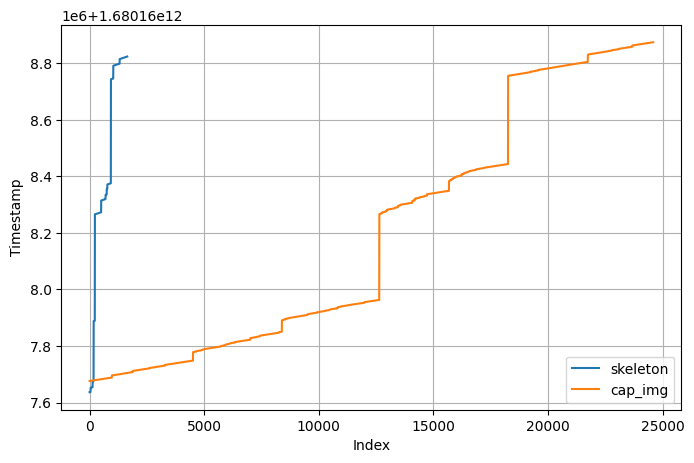

In [8]:
def plot_stamps(skeleton,cap_img):
    plt.figure(figsize=(8, 5))
    plt.plot(skeleton['Timestamp'],label='skeleton')
    plt.plot(cap_img['Timestamp'],label='cap_img')
    plt.legend()
    plt.xlabel('Index')
    plt.ylabel('Timestamp')
    plt.grid(True)
    plt.show()

plot_stamps(skeleton,cap_img)

In [9]:
skeleton.Timestamp.diff().mean()

722.9634460709259

In [10]:
cap_img.Timestamp.diff().mean()

48.754951803798754

There are some large jumps in data. We can't adress it now as we will have discountinous bins. We will remove the affected capacitive images after assignment.

It looks like MergeTimeStamps is the biggest smaller value mutiple of 5 with respect to TimeStamps.

In [11]:
# we will make both df overlap
max_cap, min_cap = max(cap_img.Timestamp), min(cap_img.Timestamp)
max_skel, min_skel = max(skeleton.Timestamp), min(skeleton.Timestamp)
print(max_skel > max_cap)
print(min_skel < min_cap)

False
True


Get overlapping between skeleton and capacitive images

In [12]:
mask_skel = (skeleton.Timestamp >= min_cap) & (skeleton.Timestamp <= max_cap)
mask_skel[mask_skel]

174     True
175     True
176     True
177     True
178     True
        ... 
1639    True
1640    True
1641    True
1642    True
1643    True
Name: Timestamp, Length: 1470, dtype: bool

In [13]:
mask_skel[mask_skel==True]

174     True
175     True
176     True
177     True
178     True
        ... 
1639    True
1640    True
1641    True
1642    True
1643    True
Name: Timestamp, Length: 1470, dtype: bool

In [14]:
skeleton=skeleton[mask_skel].reset_index(drop=True)
len(skeleton)

1470

In [15]:
len(cap_img.cap_img)

24588

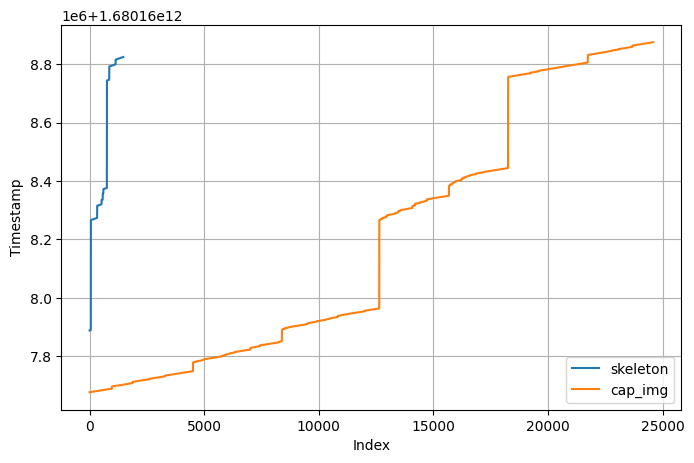

In [16]:
plot_stamps(skeleton,cap_img)

Hence we want to get 1471 observations out of 1644, we will map skeleton to average of capacitive images.

In [17]:
bins = skeleton.Timestamp
x = cap_img.Timestamp
cap_img['where_to'] = np.digitize(x, bins) 
#convert from bin to which skeleton timestamp it is superior or equal to
cap_img.where_to=cap_img.where_to.map(lambda x: x-1)
cap_img.where_to.unique()

array([  -1,   53,   71,   72,   73,   74,   75,   76,   77,   78,   79,
         80,   81,   82,   83,   84,   85,   86,   87,   88,   89,   90,
        111,  114,  115,  116,  117,  118,  119,  120,  148,  149,  150,
        151,  155,  156,  157,  158,  163,  164,  165,  167,  168,  169,
        170,  171,  172,  173,  174,  175,  176,  177,  178,  179,  180,
        181,  182,  183,  184,  204,  241,  242,  243,  244,  245,  246,
        247,  248,  249,  268,  269,  270,  271,  275,  276,  277,  285,
        286,  287,  328,  451,  452,  469,  470,  471,  472,  473,  474,
        475,  476,  477,  478,  479,  480,  481,  509,  510,  511,  512,
        520,  564,  566,  567,  568,  570,  571,  753,  856,  857,  858,
        859,  860,  861,  862,  863,  864,  865,  866,  867,  868,  869,
        870,  871,  872,  873,  874,  875,  876,  877,  878,  880,  881,
        882,  883,  884,  885,  886,  887,  888,  889,  890,  891,  892,
        893,  894,  895,  896,  897,  898,  899,  9

check, looks in order

In [18]:
display(cap_img[(cap_img.where_to==1000)].Timestamp.iloc[0])
display(cap_img[(cap_img.where_to==1000)].Timestamp.iloc[1])
display(skeleton.iloc[1000].Timestamp)
#maybe find a way to rearrange better
display(skeleton.iloc[1001].Timestamp)

1680168795532.0

1680168795546.0

1680168795527.2131

1680168795568.21

In [19]:
skeleton.Timestamp.diff().sort_values(ascending=False)

54     376691.893066
754    368034.704834
857     45180.883789
329     41485.784180
572     20275.489014
           ...      
584         7.995850
355         7.509766
254         7.000732
17          7.000732
0                NaN
Name: Timestamp, Length: 1470, dtype: float64

These are the skeleton points that present too much of a jump. We remove all capacitive images that were assigned to them

In [20]:
skeleton.Timestamp.diff().sort_values(ascending=False)

54     376691.893066
754    368034.704834
857     45180.883789
329     41485.784180
572     20275.489014
           ...      
584         7.995850
355         7.509766
254         7.000732
17          7.000732
0                NaN
Name: Timestamp, Length: 1470, dtype: float64

In [21]:
#keep it at 30 fps
threshhold = 40
ranking=skeleton.Timestamp.diff().sort_values(ascending=False)
ranking=ranking[ranking > threshhold]
ranking.index=ranking.index-1
ranking

53      376691.893066
753     368034.704834
856      45180.883789
328      41485.784180
571      20275.489014
1134     16064.123047
520      14939.534912
599      14597.821533
1448        72.798584
1312        70.291748
314         70.129395
1057        68.551270
1183        67.323730
1173        63.584473
649         63.279785
1156        62.863037
967         61.006348
490         60.997803
560         60.690674
863         60.294434
70          59.661621
1426        58.996582
1459        58.435791
1318        58.168213
1275        57.432617
1345        57.384277
222         56.510498
277         56.009277
1068        55.535645
1375        50.549561
93          49.992432
1215        48.555176
1027        46.019775
1055        45.006836
108         44.906250
164         43.998291
793         43.971680
917         43.140381
848         42.862793
914         42.161865
814         41.861816
769         41.661865
74          41.640381
1064        41.061523
500         41.006104
1072      

In [22]:
cap_img.columns

Index(['Timestamp', 'MergeTimeStamps', 'ScanSizeX', 'ScanSizeY', 'cap_img',
       'where_to'],
      dtype='object')

In [23]:
cap_img.where_to.value_counts(ascending=False)[:20]

where_to
-1       8387
 53      4248
 1469    2856
 753     2578
 856     2426
 328     1392
 571      956
 520      502
 1134     496
 1057       5
 863        5
 1021       4
 914        4
 967        4
 1068       4
 74         4
 1002       3
 877        3
 882        3
 475        3
Name: count, dtype: int64

In [24]:
cap_img[~cap_img.where_to.isin(list(ranking.index)+[-1,len(skeleton)-1])].where_to.value_counts().sort_values(ascending=False)[:20]

where_to
1132    3
958     3
157     3
1074    3
481     3
1054    3
890     3
983     3
896     3
898     3
900     3
901     3
973     3
972     3
970     3
969     3
968     3
966     3
963     3
1109    3
Name: count, dtype: int64

In [25]:
dicts = {x: 'first' for x in ['ScanSizeX', 'ScanSizeY']}
dicts['cap_img'] = 'mean'
prev = len(cap_img)
#need also to remove first and last mapping since all out of time cap_img would map there
to_remove = list(ranking.index)+[-1,len(skeleton)-1]
cap_img=cap_img[~cap_img.where_to.isin(to_remove)]
print('now', len(cap_img), 'discarded frames', prev - len(cap_img), 'out of', prev)
res=cap_img.groupby('where_to').agg(dicts)
res

now 689 discarded frames 23899 out of 24588


,ScanSizeX,ScanSizeY,cap_img
where_to,,,
71,72.0,41,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
72,72.0,41,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
73,72.0,41,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
75,72.0,41,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
76,72.0,41,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
...,...,...,...
1128,72.0,41,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1129,72.0,41,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1130,72.0,41,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


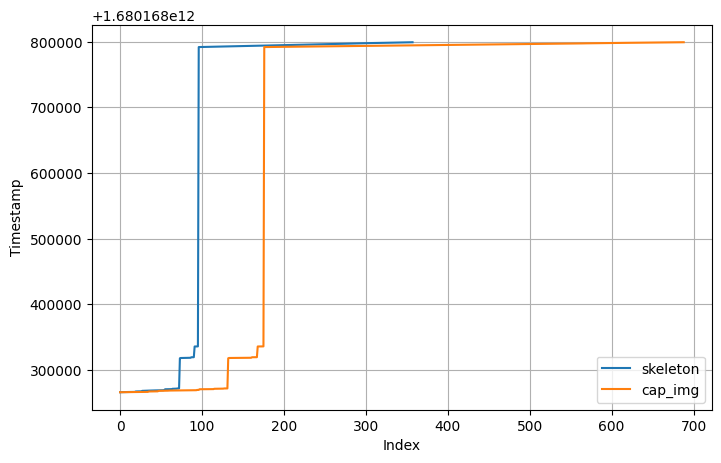

In [26]:
plot_stamps(skeleton.loc[res.index].reset_index(drop=True),cap_img.reset_index(drop=True))

In [27]:
cap_img.columns

Index(['Timestamp', 'MergeTimeStamps', 'ScanSizeX', 'ScanSizeY', 'cap_img',
       'where_to'],
      dtype='object')

In [28]:
data=skeleton.iloc[res.index]
data = pd.concat([data,res],axis=1).reset_index(drop=True)
data

,Timestamp,skeleton,ScanSizeX,ScanSizeY,cap_img
0,1.680168e+12,"[[-244.9940948486328, 272.09136962890625, 257....",72.0,41,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,1.680168e+12,"[[-245.3010711669922, 271.97235107421875, 257....",72.0,41,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,1.680168e+12,"[[-246.47927856445312, 271.7273254394531, 257....",72.0,41,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,1.680168e+12,"[[-247.63536071777344, 270.2790832519531, 256....",72.0,41,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4,1.680168e+12,"[[-248.427978515625, 269.8810119628906, 255.49...",72.0,41,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
...,...,...,...,...,...
353,1.680169e+12,"[[-264.3017883300781, 289.6992492675781, 332.8...",72.0,41,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
354,1.680169e+12,"[[-264.810546875, 288.00799560546875, 333.6176...",72.0,41,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
355,1.680169e+12,"[[-266.5947570800781, 284.7255554199219, 336.6...",72.0,41,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
356,1.680169e+12,"[[-268.9685363769531, 283.40106201171875, 338....",72.0,41,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


# Simpler approach and more efficient approach

In [29]:
def perfect_map(skeleton,cap_img,time_tolerance = 7) :
    merged_df = pd.merge_asof(
        skeleton, cap_img,
        left_on='Timestamp', right_on='Timestamp',
        direction='nearest', tolerance=time_tolerance 
    ).dropna().reset_index(drop=True)
    return merged_df.drop(columns=['ScanSizeX','ScanSizeY','MergeTimeStamps'])

In [30]:
perfect_map(skeleton,cap_img)

,Timestamp,skeleton,cap_img,where_to
0,1.680168e+12,"[[-244.9940948486328, 272.09136962890625, 257....","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",71.0
1,1.680168e+12,"[[-245.3010711669922, 271.97235107421875, 257....","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",71.0
2,1.680168e+12,"[[-246.47927856445312, 271.7273254394531, 257....","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",73.0
3,1.680168e+12,"[[-248.427978515625, 269.8810119628906, 255.49...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",76.0
4,1.680168e+12,"[[-249.43167114257807, 270.04217529296875, 254...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",76.0
...,...,...,...,...
348,1.680169e+12,"[[-264.810546875, 288.00799560546875, 333.6176...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1128.0
349,1.680169e+12,"[[-266.5947570800781, 284.7255554199219, 336.6...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1129.0
350,1.680169e+12,"[[-268.9685363769531, 283.40106201171875, 338....","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1131.0
351,1.680169e+12,"[[-268.5434265136719, 281.7997741699219, 333.3...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1132.0
